<a href="https://colab.research.google.com/github/avikumart/DA-DS-Questions/blob/main/ML_coding/Ml_coding_and_interviewn_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Eigen Vector and Eigen values

In [ ]:
import numpy as np

A = np.array([[1,2,3],[3,2,1],[1,1,1]])

# do eigen vector and eigen values of the Matrix A
eigenval , eigenvec = np.linalg.eig(A)

print(eigenval)
print(eigenvec)

[ 5.00000000e+00 -1.00000000e+00  8.95297709e-17]
[[ 6.09233653e-01  7.07106781e-01  4.08248290e-01]
 [ 7.20003408e-01 -7.07106781e-01 -8.16496581e-01]
 [ 3.32309265e-01 -6.91757621e-17  4.08248290e-01]]


In [ ]:
v = eigenvec[:,0]
lambda_ = eigenval[0]

left = A @ v
right = lambda_ * v

print("Av:\n", left)
print("\nlamba:\n", right)

Av:
 [3.04616827 3.60001704 1.66154633]

lamba:
 [3.04616827 3.60001704 1.66154633]


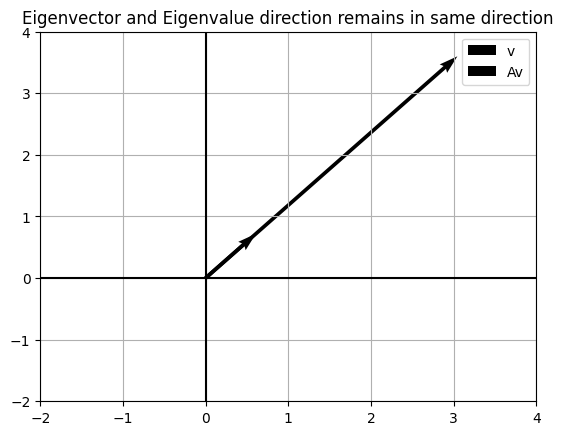

In [ ]:
import matplotlib.pyplot as plt

v = eigenvec[:,0]
Av = A @ v

plt.axhline(0, color="black")
plt.axvline(0 , color="black")


# plot the qiuver plot
plt.quiver(0,0,v[0],v[1], angles="xy", scale_units="xy", scale=1, label="v")
plt.quiver(0,0,Av[0],Av[1], angles="xy", scale_units="xy", scale=1, label="Av")

plt.legend()
plt.xlim(-2,4)
plt.ylim(-2,4)
plt.grid()
plt.title("Eigenvector and Eigenvalue direction remains in same direction")
plt.show()


In [ ]:
# applying to the PCA
from sklearn.datasets import load_iris
import numpy as np

X = load_iris().data

X_std = (X - X.mean(axis=0)) / X.std(axis=0)

cov = np.cov(X_std, rowvar=False)

eig_vals, eig_vecs = np.linalg.eig(cov)

print("Eigenvalues:\n", eig_vals)
print("\nEiganvectors (principal components):\n", eig_vecs)

Eigenvalues:
 [2.93808505 0.9201649  0.14774182 0.02085386]

Eiganvectors (principal components):
 [[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]


In [ ]:
explained_variance = eig_vals / eig_vals.sum()
explained_variance

array([0.72962445, 0.22850762, 0.03668922, 0.00517871])

## Gradient Descent

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

X = np.linspace(0, 10, 50)
y = 3*X + 5 + np.random.randn(50)*2

In [ ]:
# step 2 - initialize the params
m = 0
c = 0
lr = 0.01

# step 3 - Implement Gradient Descent loop
losses = []

for epoch in range(500):
  y_pred = m*X + c

  dm = (-2/len(X)) * np.sum(X * (y - y_pred))
  dc = (-2/len(X)) * np.sum(y - y_pred)

  # update weights
  m = m -lr*dm
  c = c - lr*dc

  # compute loss
  loss = np.mean((y - y_pred)**2)
  losses.append(loss)

print("Learned slope m:", m)
print("Learned intercept c:", c)

Learned slope m: 2.791232212001275
Learned intercept c: 6.201066048318193


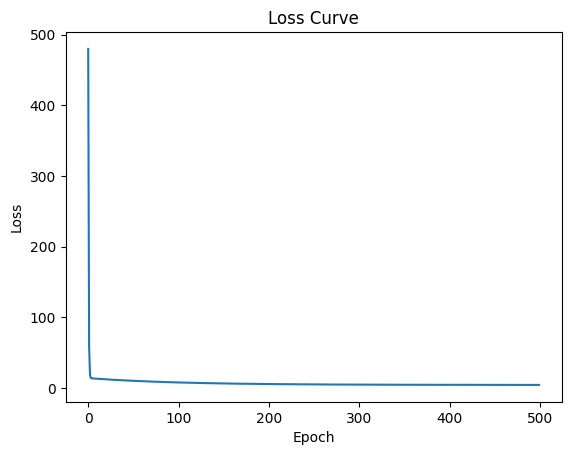

In [ ]:
# plot the loss curve
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.show()

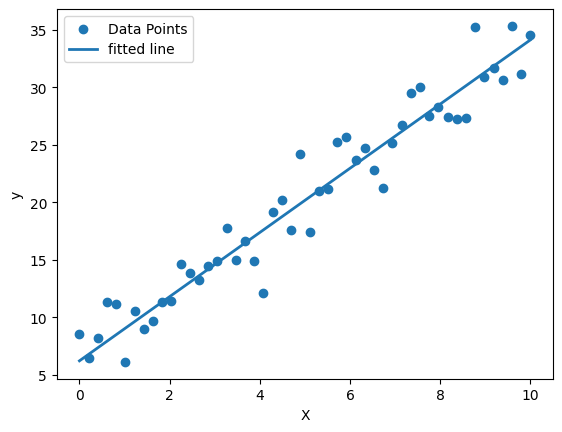

In [ ]:
# visualize the fitted line
plt.scatter(X, y, label="Data Points")
plt.plot(X, m*X + c, label="fitted line", linewidth=2)
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## SGD compute

In [ ]:
# compute the SGD
m, c = 0, 0
lr = 0.01
SGD_losses = []

for epoch in range(1000):
  i = np.random.randint(0, len(X))
  Xi = X[i]
  yi = y[i]

  y_pred = m*Xi + c

  # gradients
  dm = -2 * Xi * (yi - y_pred)
  dc = -2 * (yi - y_pred)

  m = m - lr*dm
  c = c - lr*dc

  # full dataset loss
  y_pred_loss = m*X + c
  loss = np.mean((y - y_pred_loss)**2)
  SGD_losses.append(loss)

print("Learned slope m:", m)
print("Learned intercept c:", c)

Learned slope m: 3.112224009998901
Learned intercept c: 6.904694418352389


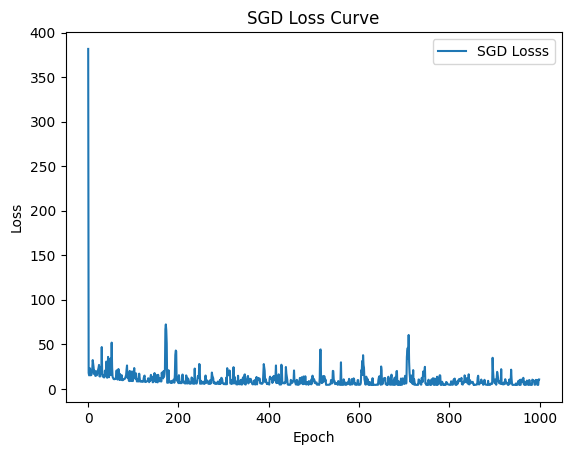

In [ ]:
# plot the SGD losses
plt.plot(SGD_losses, label="SGD Losss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SGD Loss Curve")
plt.legend()
plt.show()

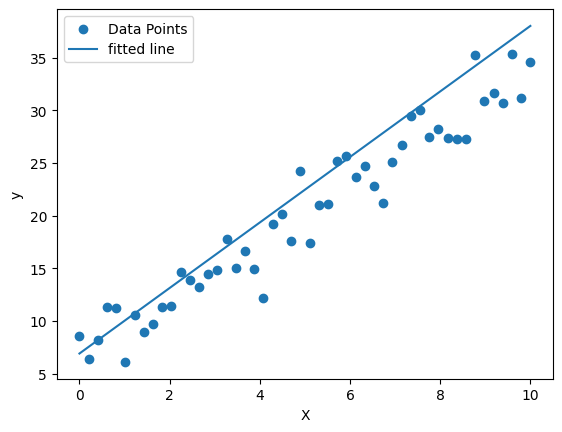

In [ ]:
plt.scatter(X, y, label="Data Points")
plt.plot(X, m*X + c, label="fitted line")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## Mini batch gradient descent

In [ ]:
m ,c = 0, 0
lr = 0.01
batch_size = 10
minibatch_losses = []

for eppoch in range(500):
  i = np.random.choice(len(X), size=batch_size, replace=False)
  Xi = X[i]
  yi = y[i]

  y_pred = m*Xi + c

  dm = (-2/batch_size) * np.sum(Xi * (yi - y_pred))
  dc = (-2/batch_size) * np.sum(yi - y_pred)

  m = m - lr*dm
  c = c - lr*dc

  y_pred_loss = m*X + c
  loss = np.mean((y - y_pred_loss)**2)
  minibatch_losses.append(loss)

print("Learned slope m:", m)
print("Learned intercept c:", c)

Learned slope m: 2.6549225110576367
Learned intercept c: 6.2412648768651415


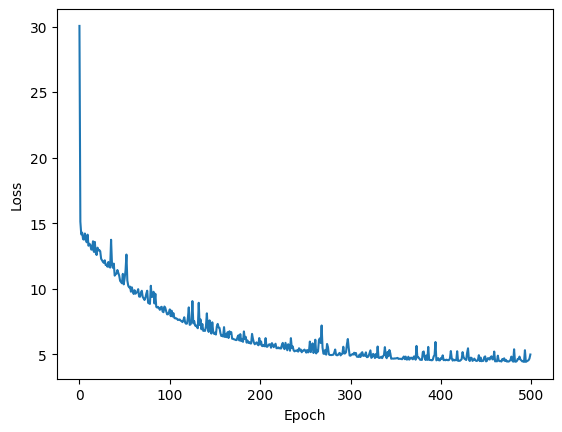

In [ ]:
# plot the mini_batch loss
plt.plot(minibatch_losses, label="Mini-batch Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

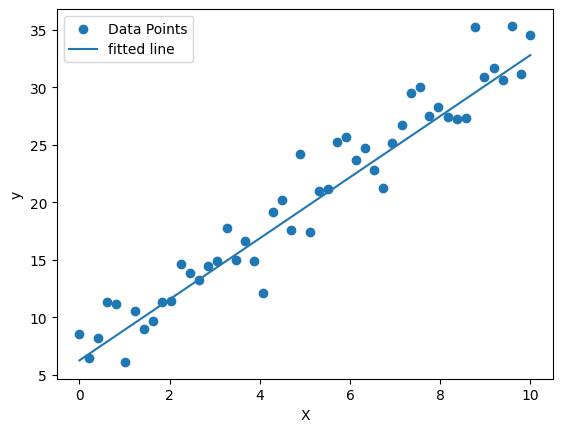

In [ ]:
# plot the scatter plot of the predictions
plt.scatter(X, y, label="Data Points")
plt.plot(X, m*X + c, label="fitted line")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## Underfitting, overfitting and balanced


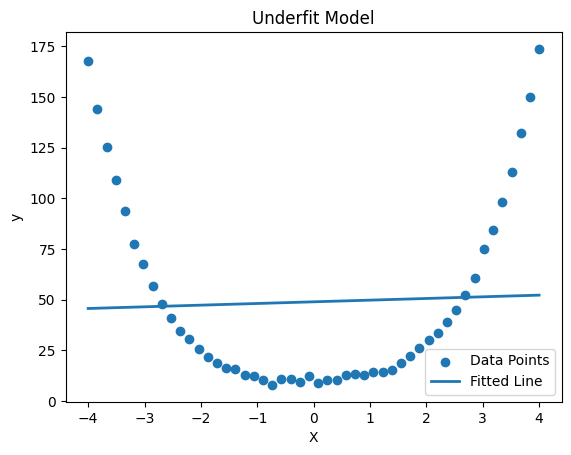

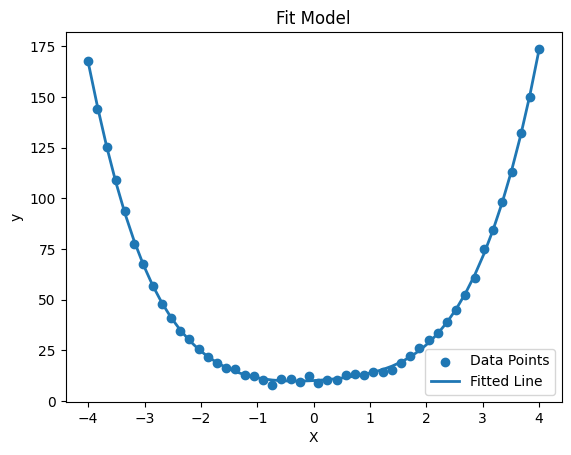

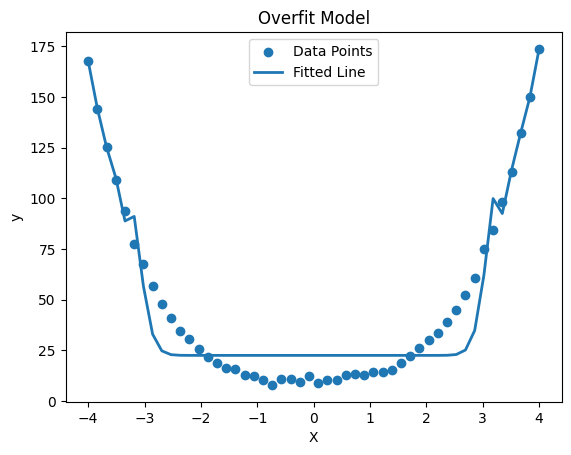

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# create dataset
np.random.seed(0)
X = np.linspace(-4, 4, 50)
y = 0.5 * X**4 - 2 + 2*X**2 + X + 12 + np.random.randn(50)
X = X.reshape(-1, 1)

# create polynomial features
def polyfeatures(degree, title):
  poly = PolynomialFeatures(degree=degree)
  X_poly = poly.fit_transform(X)

  # fit the linear regression model
  model = LinearRegression()
  model.fit(X_poly, y)

  # predict the values
  X_grid = np.linspace(-4, 4, 50).reshape(-1, 1)
  X_grid_poly = poly.transform(X_grid)
  y_pred = model.predict(X_grid_poly)

  # plot the data
  plt.scatter(X, y, label="Data Points")
  plt.plot(X_grid, y_pred, label="Fitted Line", linewidth=2)
  plt.xlabel("X")
  plt.ylabel("y")
  plt.title(title)
  plt.legend()
  plt.show()

# underfit model
polyfeatures(1, "Underfit Model")

# fit model
polyfeatures(10, "Fit Model")

# overfit
polyfeatures(50, "Overfit Model")

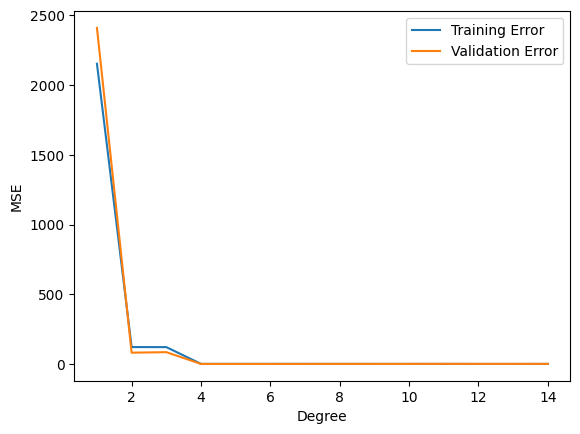

In [14]:
# train and validation loss curves (under/overfit)
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

x_train, x_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

train_errors = []
val_errors = []

degrees = range(1,15)

for d in degrees:
  poly = PolynomialFeatures(d)
  X_train_poly = poly.fit_transform(x_train)
  X_val_poly = poly.transform(x_val)

  model = LinearRegression()
  model.fit(X_train_poly, y_train)

  train_pred = model.predict(X_train_poly)
  val_pred = model.predict(X_val_poly)

  train_errors.append(mean_squared_error(y_train, train_pred))
  val_errors.append(mean_squared_error(y_val, val_pred))

# plot the errors
plt.plot(degrees, train_errors, label="Training Error")
plt.plot(degrees, val_errors, label="Validation Error")
plt.xlabel("Degree")
plt.ylabel("MSE")
plt.legend()
plt.show()

## Regularization (Ridge, Lasso, ElasticNet)

In [15]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

poly = PolynomialFeatures(degree=10)
X_poly = poly.fit_transform(X)

# Ridge
ridge = Ridge(alpha=0.1)
ridge.fit(X_poly, y)

# lasso
lasso = Lasso(alpha=0.1)
lasso.fit(X_poly, y)

# elastic
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic.fit(X_poly, y)


# print the model weights
print("ridge coeffs", ridge.coef_)
print("lasso coeffs", lasso.coef_)
print("elastic coeffs", elastic.coef_)

ridge coeffs [ 0.00000000e+00  1.48663888e+00  1.95415698e+00 -4.20776710e-01
  5.40834798e-01  8.69632077e-02 -1.04362193e-02 -6.99906562e-03
  9.51366153e-04  1.89770548e-04 -2.77364387e-05]
lasso coeffs [ 0.00000000e+00  6.90431006e-01  2.03817198e+00  4.43924753e-02
  4.67309702e-01 -2.01620896e-03  3.48683468e-03 -1.99970809e-04
 -2.26967840e-05  1.04451120e-05 -4.67545824e-06]
elastic coeffs [ 0.00000000e+00  6.91288113e-01  1.88483862e+00  5.29546193e-02
  5.00892113e-01 -3.69563236e-03  1.31288914e-03 -1.06770074e-04
 -1.94427531e-05  9.13595672e-06 -2.34840361e-06]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.314e+01, tolerance: 1.087e+01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.057e+01, tolerance: 1.087e+01
  model = cd_fast.enet_coordinate_descent(
